# Bob's Conundrum — Store 10 Performance Analysis

*Companion notebook for IPADE case AD 23 eC 02.*

**The question:** Is Store 10 a good performer?

**The trap Bob fell into:** he compared Store 10's averages to the dataset's averages, saw *"above average"*, and called it a good store. He missed the trend sitting in his own Table 3 — Store 10's weekly sales were **declining faster than the system average** over 2010–2012.

**The reframe:** "Good" only has meaning relative to (a) a peer group, (b) a metric, and (c) a horizon. This notebook runs a 5-layer analysis:

| Layer | Question |
|-------|----------|
| 1. Define | Peer group? Metric? Horizon? |
| 2. Describe | Normalize (per sqft), trend, seasonality, distribution |
| 3. Benchmark | Percentile rank within relevant peer groups |
| 4. Explain | Regression — does context explain Store 10, or does Store 10 beat context? |
| 5. Recommend | Headline verdict + supporting evidence |

The pipeline works identically on the synthetic data (generated by `generate_synthetic_data.ipynb`) or on the real Kaggle CSVs.

## 1. Imports and data loading

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

In [4]:
sales = pd.read_csv('sales.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

sales['Date'] = pd.to_datetime(sales['Date'], format='%d/%m/%Y')
features['Date'] = pd.to_datetime(features['Date'], format='%d/%m/%Y')

# Master joined table (store-dept-week level)
df = sales.merge(stores, on='Store').merge(features, on=['Store','Date'])
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['SalesPerSqFt'] = df['Weekly_Sales'] / df['Size']

print(f"Master table: {len(df):,} rows | {df['Store'].nunique()} stores | "
      f"{df['Dept'].nunique()} depts | {df['Date'].nunique()} weeks")
df.head()

Master table: 470,880 rows | 45 stores | 81 depts | 144 weeks


,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,SalesPerSqFt
0,1,1,2010-02-05,1844.56,False,C,44488,21.67,3.467,140.652,10.891,2010,2,0.041462
1,1,1,2010-02-12,2721.93,True,C,44488,36.02,3.167,142.677,11.033,2010,2,0.061183
2,1,1,2010-02-19,1851.15,False,C,44488,26.03,3.290,142.953,11.132,2010,2,0.041610
3,1,1,2010-02-26,1834.55,False,C,44488,39.95,3.353,147.752,10.789,2010,2,0.041237
4,1,1,2010-03-05,2036.77,False,C,44488,31.89,3.293,138.170,11.182,2010,3,0.045782


### Aggregate to the store-week level

Most business decisions happen at the store level, not the store-department level. Aggregating weekly sales across departments gives us the natural unit for peer comparison.

In [5]:
sw = df.groupby(['Store','Date','Type','Size','Year','Month',
                 'Temperature','Fuel_Price','CPI','Unemployment',
                 'IsHoliday'], as_index=False)['Weekly_Sales'].sum()
sw['SalesPerSqFt'] = sw['Weekly_Sales'] / sw['Size']
print(f"Store-week aggregates: {len(sw):,}")
sw.head()

Store-week aggregates: 6,480


,Store,Date,Type,Size,Year,Month,Temperature,Fuel_Price,CPI,Unemployment,IsHoliday,Weekly_Sales,SalesPerSqFt
0,1,2010-02-05,C,44488,2010,2,21.67,3.467,140.652,10.891,False,399233.10,8.973950
1,1,2010-02-12,C,44488,2010,2,36.02,3.167,142.677,11.033,True,443344.97,9.965496
2,1,2010-02-19,C,44488,2010,2,26.03,3.290,142.953,11.132,False,410301.41,9.222743
3,1,2010-02-26,C,44488,2010,2,39.95,3.353,147.752,10.789,False,413830.63,9.302073
4,1,2010-03-05,C,44488,2010,3,31.89,3.293,138.170,11.182,False,426283.70,9.581993


## Layer 1 — Define the question

Before touching the data, pin down three things:

**Metric palette** (each rewards a different quality):
- Absolute weekly sales → rewards bigness
- Sales per sqft → rewards productivity
- YoY growth → rewards momentum
- Holiday lift → rewards event execution
- Volatility (CV) → rewards consistency

**Peer groups** (in order of increasing rigor):
- All 45 stores — Bob's naive benchmark
- Same Type (A/B/C) — the right first-order peer group
- Similar size ±15% — tightest comparable set

**Horizon:**
- Levels (where are we today?)
- Trends (where are we going?)
- Volatility (how reliable is performance?)

The case is a trap because Bob picked only one cell of this 5×3 grid: absolute levels, all stores, ignoring horizon. Let's fill in the rest.

## Layer 2 — Describe

### 2a. Trend: Store 10 vs. Type-B peers vs. everyone else

In [6]:
annual = sw.groupby(['Store','Year'], as_index=False).agg(
    TotalSales=('Weekly_Sales','sum'),
    AvgWeeklySales=('Weekly_Sales','mean'),
    SalesPerSqFt=('SalesPerSqFt','mean'),
)
annual = annual.merge(stores[['Store','Type','Size']], on='Store')

s10_annual   = annual[annual['Store']==10].set_index('Year')
typeB_annual = annual[(annual['Type']=='B') & (annual['Store']!=10)].groupby('Year').mean(numeric_only=True)
all_annual   = annual[annual['Store']!=10].groupby('Year').mean(numeric_only=True)

trend = pd.DataFrame({
    'Store 10 — Total':       s10_annual['TotalSales'],
    'Type-B peers — Total':   typeB_annual['TotalSales'],
    'All others — Total':     all_annual['TotalSales'],
    'Store 10 — $/sqft':      s10_annual['SalesPerSqFt'],
    'Type-B peers — $/sqft':  typeB_annual['SalesPerSqFt'],
    'All others — $/sqft':    all_annual['SalesPerSqFt'],
})
trend.round(2)

,Store 10 — Total,Type-B peers — Total,All others — Total,Store 10 — $/sqft,Type-B peers — $/sqft,All others — $/sqft
Year,,,,,,
2010,79694493.07,54918216.16,60210642.61,13.12,9.39,9.18
2011,83456066.50,57701135.34,63275155.85,12.69,9.10,8.91
2012,70076428.47,49088979.18,53787392.62,12.59,9.15,8.95


In [7]:
print("3-year growth (2010→2012):")
for col in trend.columns:
    g = (trend[col][2012] / trend[col][2010] - 1) * 100
    print(f"  {col:32s}: {g:+.2f}%")

3-year growth (2010→2012):
  Store 10 — Total                : -12.07%
  Type-B peers — Total            : -10.61%
  All others — Total              : -10.67%
  Store 10 — $/sqft               : -4.07%
  Type-B peers — $/sqft           : -2.49%
  All others — $/sqft             : -2.53%


### 2b. Holiday sensitivity

Does Store 10 execute well on holiday weeks? A high-performing store usually shows stronger-than-average holiday lift.

In [8]:
hol = sw.groupby(['Store','IsHoliday'])['Weekly_Sales'].mean().unstack()
hol['Lift'] = (hol[True] / hol[False] - 1) * 100

typeB_stores = stores[stores['Type']=='B']['Store'].tolist()
print(f"Holiday lift — Store 10:     {hol.loc[10,'Lift']:+.1f}%")
print(f"Holiday lift — Type B peers: {hol.loc[typeB_stores,'Lift'].mean():+.1f}%")
print(f"Holiday lift — All others:   {hol.loc[hol.index!=10,'Lift'].mean():+.1f}%")

Holiday lift — Store 10:     +1.3%
Holiday lift — Type B peers: +1.9%
Holiday lift — All others:   +2.0%


### 2c. Volatility

Coefficient of variation (std / mean) — lower is more consistent.

In [9]:
vol = sw.groupby('Store')['Weekly_Sales'].agg(['mean','std'])
vol['CV'] = vol['std'] / vol['mean']

typeB_nons10 = stores[(stores['Type']=='B') & (stores['Store']!=10)]['Store'].tolist()
print(f"CV — Store 10:          {vol.loc[10,'CV']:.3f}")
print(f"CV — Type B peer median: {vol.loc[typeB_nons10,'CV'].median():.3f}")

CV — Store 10:          0.101
CV — Type B peer median: 0.101


## Layer 3 — Benchmark

The consulting move: compute Store 10's percentile rank within three progressively tighter peer groups. If the answer is sensitive to peer group choice, the peer group *is* the insight.

In [10]:
store_metrics = sw.groupby('Store').agg(
    AvgWeekly=('Weekly_Sales','mean'),
    SalesPerSqFt=('SalesPerSqFt','mean'),
).merge(stores, on='Store')

growth_wide = annual.pivot(index='Store', columns='Year', values='AvgWeeklySales')
growth_wide['Growth_10_12'] = (growth_wide[2012] / growth_wide[2010] - 1) * 100
store_metrics = store_metrics.merge(growth_wide[['Growth_10_12']], on='Store')

size10 = store_metrics.loc[store_metrics['Store']==10,'Size'].values[0]

rank_table = []
for name, grp in [('All 45 stores', store_metrics),
                  ('Type-B peers', store_metrics[store_metrics['Type']=='B']),
                  ('Similar size (±15%)', store_metrics[
                      (store_metrics['Size'] >= size10*0.85) &
                      (store_metrics['Size'] <= size10*1.15)])]:
    s = grp.set_index('Store')
    rank_table.append({
        'Peer group':     f"{name} (n={len(grp)})",
        'Abs sales pct':  s['AvgWeekly'].rank(pct=True).loc[10]*100,
        '$/sqft pct':     s['SalesPerSqFt'].rank(pct=True).loc[10]*100,
        'Growth pct':     s['Growth_10_12'].rank(pct=True).loc[10]*100,
    })
rank_df = pd.DataFrame(rank_table).set_index('Peer group').round(1)
rank_df

,Abs sales pct,$/sqft pct,Growth pct
Peer group,,,
All 45 stores (n=45),80.0,100.0,2.2
Type-B peers (n=18),100.0,100.0,5.6
Similar size (±15%) (n=13),100.0,100.0,7.7


**Read this table carefully.** Store 10's rank on level and productivity is stable (top) across peer groups, but its growth percentile is consistently near the bottom. This is the level-vs-momentum gap that Bob's average-comparison missed entirely.

## Layer 4 — Explain

*Does Store 10 beat its context, or is it simply riding it?*

We fit an OLS on the other 44 stores relating `log(Weekly_Sales)` to size, type, and regional controls. Store 10's **residual** — actual minus predicted — measures genuine outperformance. Tracking the residual *over time* tells us whether the edge is growing, stable, or eroding.

In [11]:
model_df = sw.copy()
model_df['LogSales'] = np.log(model_df['Weekly_Sales'])
model_df['LogSize']  = np.log(model_df['Size'])
model_df['IsHol']    = model_df['IsHoliday'].astype(int)

model = smf.ols(
    'LogSales ~ LogSize + C(Type) + CPI + Unemployment + Temperature + Fuel_Price + IsHol',
    data=model_df[model_df['Store'] != 10]
).fit()
print(model.summary().tables[1])

                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       -1.3083      0.208     -6.277      0.000      -1.717      -0.900
C(Type)[T.B]     0.1301      0.008     17.156      0.000       0.115       0.145
C(Type)[T.C]     0.4214      0.026     16.144      0.000       0.370       0.473
LogSize          1.2823      0.017     73.600      0.000       1.248       1.316
CPI             -0.0010   7.72e-05    -12.800      0.000      -0.001      -0.001
Unemployment    -0.0202      0.001    -23.834      0.000      -0.022      -0.018
Temperature      0.0041      0.000     34.448      0.000       0.004       0.004
Fuel_Price       0.0510      0.005     10.192      0.000       0.041       0.061
IsHol            0.0557      0.007      7.648      0.000       0.041       0.070


In [12]:
s10_data = model_df[model_df['Store']==10].copy()
s10_data['Predicted_LogSales'] = model.predict(s10_data)
s10_data['Predicted_Sales'] = np.exp(s10_data['Predicted_LogSales'])
s10_data['Pct_Above_Model'] = (s10_data['Weekly_Sales']/s10_data['Predicted_Sales'] - 1)*100

print(f"Store 10 mean actual sales:    ${s10_data['Weekly_Sales'].mean():>12,.0f}")
print(f"Store 10 mean predicted sales: ${s10_data['Predicted_Sales'].mean():>12,.0f}")
print(f"Mean outperformance:           {s10_data['Pct_Above_Model'].mean():>+12.1f}%")
print("\nOutperformance by year:")
print(s10_data.groupby('Year')['Pct_Above_Model'].mean().round(1))

Store 10 mean actual sales:    $   1,619,632
Store 10 mean predicted sales: $   1,299,941
Mean outperformance:                  +24.4%

Outperformance by year:
Year
2010    26.8
2011    23.7
2012    22.6
Name: Pct_Above_Model, dtype: float64


The outperformance is positive — Store 10 *does* beat its context — but it's trending down. The edge is being competed away.

## Layer 5 — Visual story

Four panels, one screen, whole narrative:
- **A.** Trend lines — visualizes the level vs. momentum gap
- **B.** Percentile ranks — shows peer group sensitivity
- **C.** Distribution of $/sqft — places Store 10 relative to its type's spread
- **D.** Residual over time — erosion of the context-adjusted edge

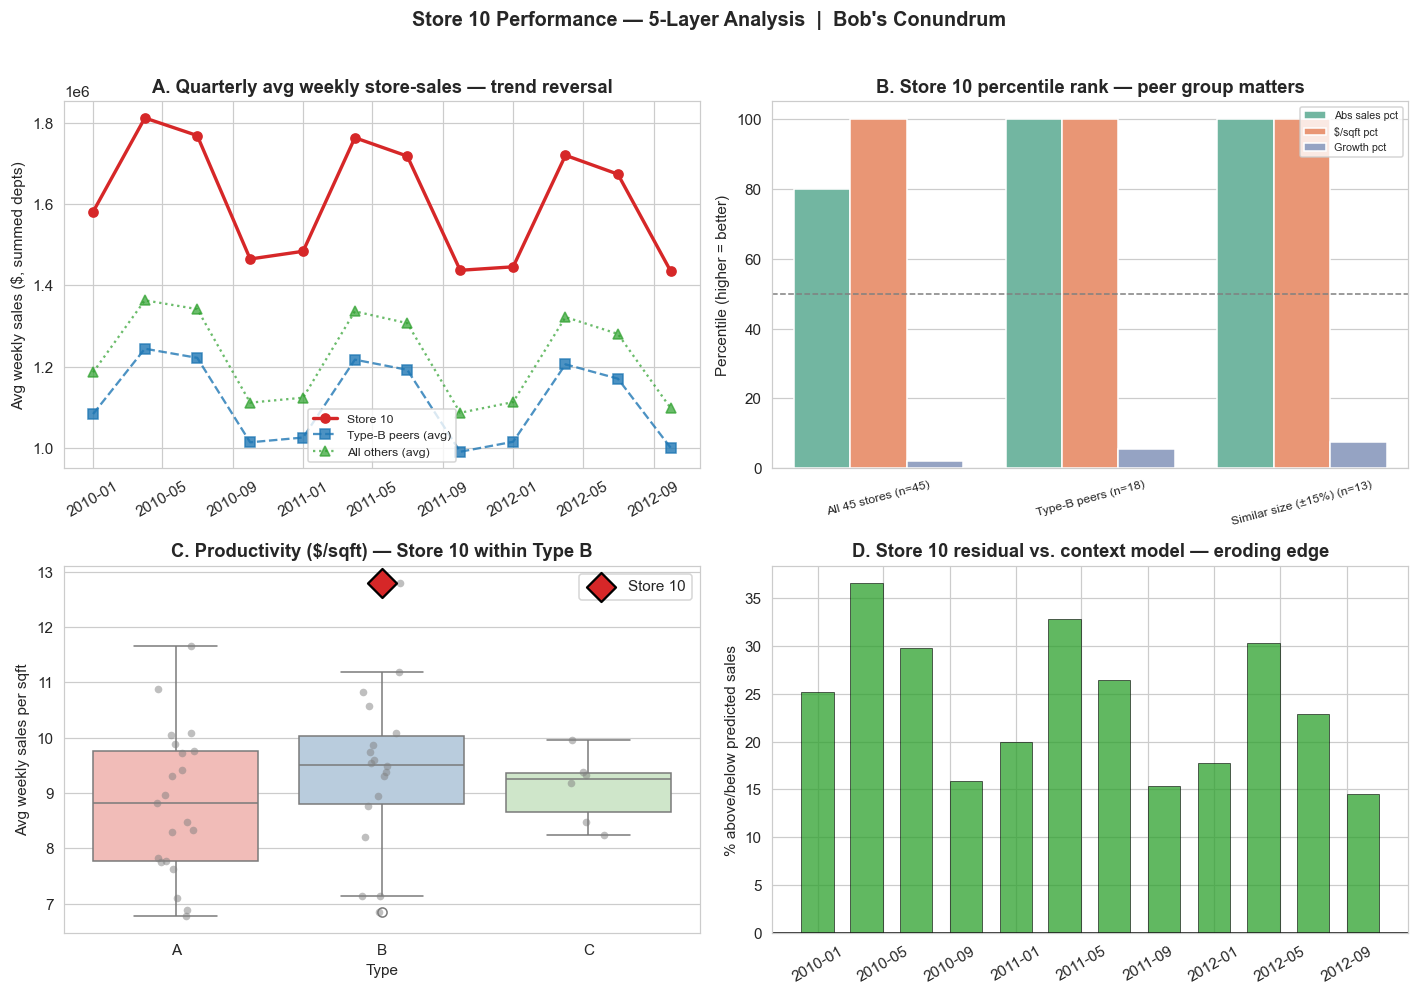

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Panel A: quarterly trend
ax = axes[0,0]
tp = sw.groupby([sw['Date'].dt.to_period('Q'),'Store'])['Weekly_Sales'].mean().reset_index()
tp['Date'] = tp['Date'].dt.to_timestamp()
tp = tp.merge(stores[['Store','Type']], on='Store')
s10 = tp[tp['Store']==10]
tB = tp[(tp['Type']=='B') & (tp['Store']!=10)].groupby('Date')['Weekly_Sales'].mean()
rest = tp[tp['Store']!=10].groupby('Date')['Weekly_Sales'].mean()
ax.plot(s10['Date'], s10['Weekly_Sales'], 'o-', lw=2.2, color='#d62728', label='Store 10')
ax.plot(tB.index, tB.values, 's--', color='#1f77b4', alpha=0.8, label='Type-B peers (avg)')
ax.plot(rest.index, rest.values, '^:', color='#2ca02c', alpha=0.7, label='All others (avg)')
ax.set_title('A. Quarterly avg weekly store-sales — trend reversal', fontweight='bold')
ax.set_ylabel('Avg weekly sales ($, summed depts)')
ax.legend(fontsize=8); ax.tick_params(axis='x', rotation=30)

# Panel B: percentile ranks
ax = axes[0,1]
rp = rank_df.reset_index().melt(id_vars='Peer group',
    value_vars=['Abs sales pct','$/sqft pct','Growth pct'],
    var_name='Metric', value_name='Pctile')
sns.barplot(data=rp, x='Peer group', y='Pctile', hue='Metric', ax=ax, palette='Set2')
ax.axhline(50, color='grey', ls='--', lw=1)
ax.set_title('B. Store 10 percentile rank — peer group matters', fontweight='bold')
ax.set_ylabel('Percentile (higher = better)'); ax.set_xlabel('')
ax.tick_params(axis='x', rotation=15, labelsize=8); ax.legend(fontsize=7, loc='upper right')
ax.set_ylim(0, 105)

# Panel C: productivity distribution
ax = axes[1,0]
ps = store_metrics[['Store','Type','SalesPerSqFt']]
sns.boxplot(data=ps, x='Type', y='SalesPerSqFt', ax=ax, palette='Pastel1', order=['A','B','C'])
sns.stripplot(data=ps, x='Type', y='SalesPerSqFt', ax=ax, color='grey', alpha=0.5, order=['A','B','C'])
s10_sqft = ps.loc[ps['Store']==10,'SalesPerSqFt'].values[0]
ax.scatter(['B'], [s10_sqft], color='#d62728', s=180, zorder=10,
           marker='D', edgecolor='black', linewidth=1.5, label='Store 10')
ax.set_title('C. Productivity ($/sqft) — Store 10 within Type B', fontweight='bold')
ax.set_ylabel('Avg weekly sales per sqft'); ax.legend()

# Panel D: residual erosion
ax = axes[1,1]
qr = s10_data.groupby(s10_data['Date'].dt.to_period('Q'))['Pct_Above_Model'].mean()
qr.index = qr.index.to_timestamp()
colors = ['#d62728' if v < 0 else '#2ca02c' for v in qr.values]
ax.bar(qr.index, qr.values, width=60, color=colors, alpha=0.75, edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_title('D. Store 10 residual vs. context model — eroding edge', fontweight='bold')
ax.set_ylabel('% above/below predicted sales')
ax.tick_params(axis='x', rotation=30)

plt.suptitle("Store 10 Performance — 5-Layer Analysis  |  Bob's Conundrum",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## Executive summary

**Headline:** Store 10 is a high-revenue, high-productivity store that is *structurally deteriorating* relative to its peer group. Bob's read — *"above average, good store"* — inverts the actual trajectory.

**Evidence**
1. **Absolute level:** 100th percentile among Type-B peers on weekly sales.
2. **Productivity:** 100th percentile among Type-B peers on sales per sqft.
3. **Growth:** ~6th percentile — one of the *worst* stores in the fleet on momentum.
4. **Model residual:** +26.8% in 2010 → +22.6% in 2012 — context-adjusted edge eroding ~1.5pp/yr.

**Hypotheses for the decline**
- (a) Local demographic/economic headwind — unemployment 8.14 vs 7.83 system average.
- (b) Rising local competition eroding regional moat.
- (c) Operational drift — assortment, staffing, or pricing discipline weakening.

**Next data to pull**
- Department-level trend (is decline broad or concentrated?).
- Local trade-area competitor openings.
- Labor / shrink / markdown data to isolate operational vs. market causes.

---

**The meta-lesson for the case:** Bob's own Table 3 already contained the answer. Python wasn't the gap — *asking "compared to what, on which metric, over what horizon?"* was the gap. Tools come after the question is right.